 # Part 1: Neural Network Fundamentals and Training Behavior Analysis

# Task 1: Dataset Understanding

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv('/content/drive/MyDrive/Data/Assignment 5/part_1_neural_network_analysis/customer_churn_nn.csv')

print("="*50)
print("Task 1: Dataset Understanding")
print("="*50)

print("-"*50)
print("1.1 Shape")
print("-"*50)

print(f" Rows : {df.shape[0]}")
print(f" Columns : {df.shape[1]}")

print("-"*50)
print("1.2 Data Types")
print("-"*50)

print(df.dtypes)

cat_cols = ['region', 'plan_type','contract_type','payment_method']
num_cols = ['tenure_months', 'monthly_charges_inr','avg_login_days_per_month','support_tickets_last_90_days','payment_delay_days','data_usage_gb','satisfaction_score','last_complaint_days_ago','discount_percent','autopay_enabled','referral_count']

print("-"*50)
print(f" Categorical Columns : {cat_cols}")
print(f" Numerical Columns : {num_cols}")
print("-"*50)

print("1.3 Target Variable Discription")
print("-"*50)
print(f"Target Variable : {df['churn'].value_counts()}")

print("-"*50)
print("1.4 Checking Missing Values")
print("-"*50)

print(f' Missing Vlaues : {df.isnull().sum().sum()}')

print("-"*50)
print("1.5 Statistical Summary")
print("-"*50)

print(df[num_cols].describe().T.round(2).to_string())

print("-"*50)
print("1.6 Target Variable Distribution")
print("-"*50)

vc = df['churn'].value_counts()
for label, count in vc.items():
  if label == 0:
    tag = 'retained'
  else:
    tag = 'churned'
  print(f'Class {label} ({tag} : {count}) ({count/len(df)*100:.2f}%)')

Task 1: Dataset Understanding
--------------------------------------------------
1.1 Shape
--------------------------------------------------
 Rows : 2000
 Columns : 17
--------------------------------------------------
1.2 Data Types
--------------------------------------------------
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object
--------------------

# Task 2: Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("="*50)
print("Task 2: Data Preprocessing")
print("="*50)

print("Droping Identifier Table: Customer_ID")
df= df.drop(columns= ['customer_id'])
print(f'Shape after dropping : {df.shape}')

print('-'*50)
print('2.1 Handling Missing Values')
print('-'*50)

missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
  print("No missing values found")

else:
  print("Missing values found....filling with column mean")
  df.fillna(df.mean, inplace= True)

print('-'*50)
print("2.2 Encoding (one-hot encoding)")
print('-'*50)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
print(df_encoded.shape)

new_cols = []
for c in df_encoded.columns:
  for cat in cat_cols:
    if c.startswith(cat):
      new_cols.append(c)
      break
for cols in new_cols:
      print(f'-> {cols}')

print('-'*50)
print("2.3 Scaling")
print('-'*50)

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
print("Scaling Done")

print('-'*50)
print("2.4 Splitting the Dataset")
print('-'*50)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= .2, random_state=42, stratify = y)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape : {y_test.shape}")


Task 2: Data Preprocessing
Droping Identifier Table: Customer_ID
Shape after dropping : (2000, 16)
--------------------------------------------------
2.1 Handling Missing Values
--------------------------------------------------
No missing values found
--------------------------------------------------
2.2 Encoding (one-hot encoding)
--------------------------------------------------
(2000, 29)
-> region_Central
-> region_East
-> region_North
-> region_South
-> region_West
-> plan_type_Basic
-> plan_type_Enterprise
-> plan_type_Premium
-> plan_type_Standard
-> contract_type_Month-to-month
-> contract_type_One-year
-> contract_type_Two-year
-> payment_method_Credit Card
-> payment_method_Debit Card
-> payment_method_Net Banking
-> payment_method_UPI
-> payment_method_Wallet
--------------------------------------------------
2.3 Scaling
--------------------------------------------------
Scaling Done
--------------------------------------------------
2.4 Splitting the Dataset
------------

# Task 3: Neural Network Model Building

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("="*50)
print("Task 3: Neural Network Model Building")
print("="*50)

print("-"*50)
print("3.1 Input Layer")
print("-"*50)

input_size = X_train.shape[1]
print(f"Input Size : {input_size}")

print('-'*50)
print("3.2 , 3.3 , 3.4 -- Build Neural Network")
print('-'*50)

model = keras.Sequential([

    # INPUT LAYER
    layers.Input(shape = (input_size,)),

    # HIDDEN LAYER 1
    layers.Dense(64, activation = 'relu'),

    # HIDDEN LAYER 2
    layers.Dense(32, activation = 'relu'),

    # OUTPUT LAYER
    layers.Dense(1, activation = 'sigmoid')

])

print(" Input Layer : 28 features ")
print(" Hidden Layer 1 : 64 neurons, ReLU activation")
print(" Hidden Layer 2 : 32 neurons, ReLU activation")
print(" Output Layer : 1 neuron, Sigmoid activation")


print('-'*50)
print("3.5 , 3.6 -- Compile the Model")
print('-'*50)

model.compile (

    # Optimizer
    optimizer = "adam",

    # Loss Function
    loss = "binary_crossentropy",

    # Metrics
    metrics = ["accuracy"]
)

print(" Optimizer : 'Adam' ")
print(" Loss Function : 'Binary Cross Entropy' ")
print(" Metrics : 'Accuracy' ")



Task 3: Neural Network Model Building
--------------------------------------------------
3.1 Input Layer
--------------------------------------------------
Input Size : 28
--------------------------------------------------
3.2 , 3.3 , 3.4 -- Build Neural Network
--------------------------------------------------
 Input Layer : 28 features 
 Hidden Layer 1 : 64 neurons, ReLU activation
 Hidden Layer 2 : 32 neurons, ReLU activation
 Output Layer : 1 neuron, Sigmoid activation
--------------------------------------------------
3.5 , 3.6 -- Compile the Model
--------------------------------------------------
 Optimizer : 'Adam' 
 Loss Function : 'Binary Cross Entropy' 
 Metrics : 'Accuracy' 


# Task 4: Training and Evaluation

Task 4 : Training and Evaluation
--------------------------------------------------
Training the Model
--------------------------------------------------
Epochs : 50
Batch Size : 32
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9619 - loss: 0.2542 - val_accuracy: 0.9850 - val_loss: 0.0880
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0846 - val_accuracy: 0.9850 - val_loss: 0.0739
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0762 - val_accuracy: 0.9850 - val_loss: 0.0675
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0711 - val_accuracy: 0.9850 - val_loss: 0.0633
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0667 - val_accuracy: 0.9850 - val_loss: 0.0600
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0629 - val_accuracy: 0.9850 - val_loss: 0.0579
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 

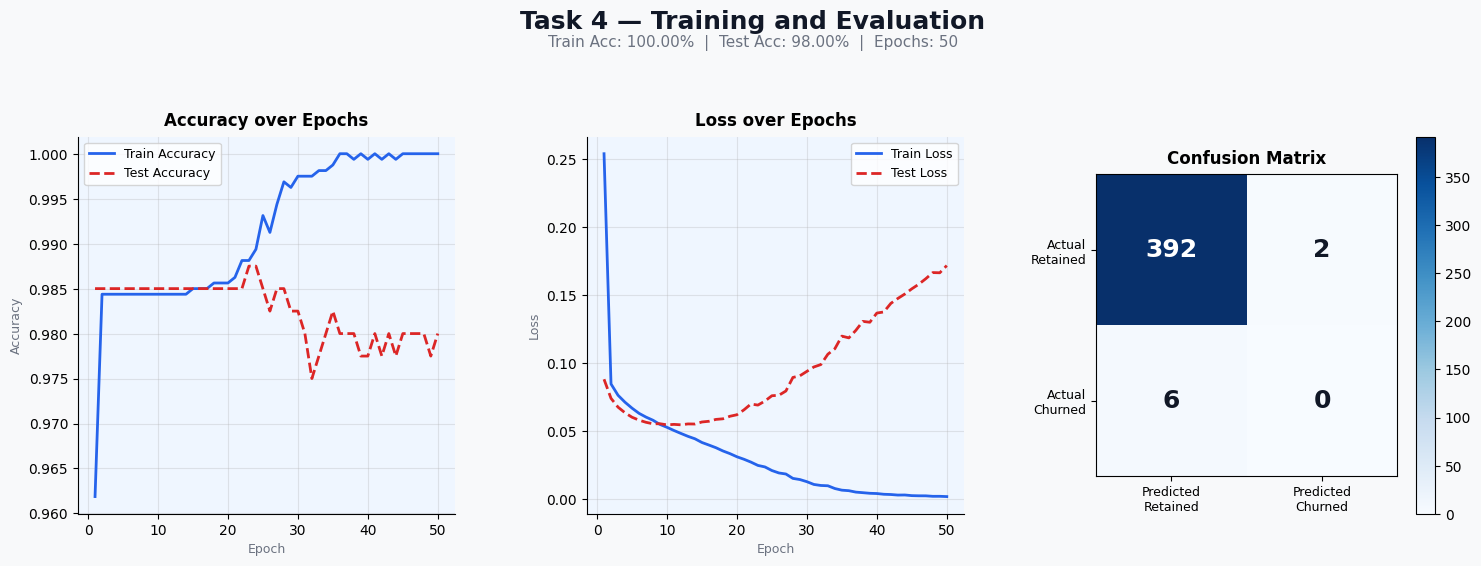

In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print('='*50)
print("Task 4 : Training and Evaluation")
print('='*50)

print('-'*50)
print("Training the Model")
print('-'*50)

print("Epochs : 50")
print("Batch Size : 32")

history = model.fit(
    X_train, y_train,
    epochs = 50,
    batch_size = 32,
    validation_data = (X_test, y_test),
    verbose = 1
)

print('-'*50)
print("4.1 , 4.2 -- Training, Testing Accuracy and Loss ")
print('-'*50)

train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]
test_loss , test_acc = model.evaluate(X_test, y_test, verbose = 0)

print(f"Training Accuracy : {train_acc*100:.2f}%")
print(f"Training Loss : {train_loss:.4f} ")
print(f"Testing Accuracy : {test_acc*100:.2f}%")
print(f"Testing Loss : {test_loss:.4f}")

print('-'*50)
print("4.3 Confusion Matrix and Evaluation Metrics ")
print('-'*50)

y_pred_prob = model.predict(X_test, verbose = 0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test,y_pred)
tn,fp,fn,tp = cm.ravel()


print(f"   │                   Predicted              │")
print(f"   │             Retained     Churned         │")
print(f"   │ Actual                                   │")
print(f"   │ Retained    {tn:4d}      {fp:4d}             │")
print(f"   │ Churned     {fn:4d}      {tp:4d}             │")

print('\n Classification Report : ')
print(classification_report(y_test,y_pred, target_names = ['Retained(0)','Churned(1)' ]))

print('-'*50)
print('4.4 Interpretation of Result')
print('-'*50)

print(f"""
   1. ACCURACY IS MISLEADING:
      The model shows {test_acc*100:.2f}% test accuracy — which looks great.
      But this is because 98.45% of customers did NOT churn.
      Even predicting everyone as "retained" gives ~98% accuracy.
      So accuracy alone is NOT a reliable metric here.

   2. CONFUSION MATRIX REVEALS THE REAL PROBLEM:
      The model predicted {fn} churned customers as "retained" (False Negatives).
      Out of only {tn+fn} actual churned customers, it missed {fn}.
      This means the model is struggling to detect the minority class (churn).

   3. CLASS IMBALANCE IS THE MAIN ISSUE:
      With only 1.55% of customers churning, the model learned to
      mostly predict "retained" because that is the safe default.
      This is a classic class imbalance problem.

   4. TRAINING vs TEST LOSS GAP:
      Training Loss : {train_loss:.4f}
      Testing  Loss : {test_loss:.4f}
      The gap shows the model has started overfitting slightly —
      it performs better on training data than on unseen test data.

   5. WHAT THIS MEANS FOR BUSINESS:
      Missing churned customers (False Negatives) is costly.
      A business wants to catch customers likely to leave
      so they can offer retention deals. A model that misses
      churned customers provides little business value.

   RECOMMENDATION:
      → Use class_weight to penalise missing churn predictions
      → Evaluate using F1-score and AUC-ROC instead of accuracy
      → Try SMOTE to oversample the minority class
""")




fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

BLUE  = '#2563EB'
GREEN = '#16A34A'
RED   = '#DC2626'
GRAY  = '#6B7280'
LIGHT = '#EFF6FF'

fig.text(0.5, 0.97, 'Task 4 — Training and Evaluation',
         fontsize=18, fontweight='bold', ha='center', color='#111827')
fig.text(0.5, 0.955,
         f'Train Acc: {train_acc*100:.2f}%  |  Test Acc: {test_acc*100:.2f}%  |  Epochs: 50',
         fontsize=11, ha='center', color=GRAY)

epochs_range = range(1, 51)

print('-'*50)
print('Plot: Accuracy')
print('-'*50)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, history.history['accuracy'],
         color=BLUE, linewidth=2, label='Train Accuracy')
ax1.plot(epochs_range, history.history['val_accuracy'],
         color=RED, linewidth=2, linestyle='--', label='Test Accuracy')
ax1.set_title('Accuracy over Epochs', fontweight='bold', fontsize=12, pad=8)
ax1.set_xlabel('Epoch', fontsize=9, color=GRAY)
ax1.set_ylabel('Accuracy', fontsize=9, color=GRAY)
ax1.legend(fontsize=9)
ax1.set_facecolor(LIGHT)
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

print("Done")



print('-'*50)
print('Plot: Loss')
print('-'*50)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, history.history['loss'],
         color=BLUE, linewidth=2, label='Train Loss')
ax2.plot(epochs_range, history.history['val_loss'],
         color=RED, linewidth=2, linestyle='--', label='Test Loss')
ax2.set_title('Loss over Epochs', fontweight='bold', fontsize=12, pad=8)
ax2.set_xlabel('Epoch', fontsize=9, color=GRAY)
ax2.set_ylabel('Loss', fontsize=9, color=GRAY)
ax2.legend(fontsize=9)
ax2.set_facecolor(LIGHT)
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

print("Done")

print('-'*50)
print('Plot: Confusion Matrix')
print('-'*50)

ax3 = fig.add_subplot(gs[0, 2])
cm_display = [[tn, fp], [fn, tp]]
im = ax3.imshow(cm_display, cmap='Blues')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Predicted\nRetained', 'Predicted\nChurned'], fontsize=9)
ax3.set_yticklabels(['Actual\nRetained', 'Actual\nChurned'], fontsize=9)
ax3.set_title('Confusion Matrix', fontweight='bold', fontsize=12, pad=8)
for i in range(2):
    for j in range(2):
        val = cm_display[i][j]
        color = 'white' if val > 200 else '#111827'
        ax3.text(j, i, str(val), ha='center', va='center',
                 fontsize=18, fontweight='bold', color=color)
plt.colorbar(im, ax=ax3)

print("Done")

plt.savefig('task4_training_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())

# Task 5: Hyperparameter Experimentation

In [6]:
from sklearn.metrics import f1_score

print("=" * 50)
print("  TASK 5: HYPERPARAMETER EXPERIMENTATION")
print("=" * 50)

experiments = [

    {
        'name' : 'Baseline Model',
        'layers' : [64,32] ,
        'activation' : 'relu' ,
        'lr' : 0.001 ,
        'batch_size' : 32 ,
        'epochs' : 50 ,
        'change' : 'Base Model'
    },
    {
        'name' : 'Ex 1 -- More Neurons & Layers',
        'layers' : [128,64,32] ,
        'activation' : 'relu' ,
        'lr' : 0.001 ,
        'batch_size' : 32 ,
        'epochs' : 50 ,
        'change' : 'Adding one more layer and more neurons'
    },
    {
        'name' : 'Ex 2 -- Higher Learning Rate' ,
        'layers' : [64,32] ,
        'activation' : 'relu' ,
        'lr' : 0.01 ,
        'batch_size' : 32 ,
        'epochs' : 50 ,
        'change' : 'Increasing Learning Rate from 0.001 to 0.01'
    },
    {
        'name' : 'Ex 3 -- tanh Activation Function' ,
        'layers' : [64,32] ,
        'activation' : 'tanh' ,
        'lr' : 0.001 ,
        'batch_size' : 32 ,
        'epochs' : 50 ,
        'change' : 'Using tanh as activation function'
    },
]

results = []
histories = []

for i,exp in enumerate(experiments):
  print('-'*50)
  print(f'{exp['name']}')
  print('-'*50)
  print(f' What changed : {exp['change']}')
  print(f' Hidden Layers : {exp['layers']}')
  print(f' Learning Rate : {exp['lr']}')
  print(f' Activation Function : {exp['activation']}')
  print(f' Batch Size : {exp['batch_size']}')
  print(f' Epochs : {exp['epochs']}')
  print(f' Training................')



  model_layers = [layers.Input(shape = (input_size,))]
  for neurons in exp['layers']:
    model_layers.append(layers.Dense(neurons, activation = exp['activation']))
  model_layers.append(layers.Dense(1, activation = 'sigmoid'))

  model = keras.Sequential(model_layers)
  model.compile (
      optimizer = keras.optimizers.Adam(learning_rate = exp['lr']),
      loss = 'binary_crossentropy',
      metrics = ['accuracy']
  )

  history = model.fit (
      X_train , y_train,
      epochs = exp['epochs'],
      batch_size = exp['batch_size'],
      validation_data = (X_test,y_test),
      verbose = 0
  )

  histories.append(history)

  test_loss , test_acc = model.evaluate(X_test, y_test, verbose = 0)
  train_acc = history.history['accuracy'][-1]
  train_loss = history.history['loss'][-1]
  y_pred = (model.predict(X_test, verbose = 0)> 0.5).astype(int).flatten()
  f1 = f1_score(y_test, y_pred, zero_division = 0)


  print(f' Train Accuracy : {train_acc*100:.2f}%')
  print(f' Test Accuracy : {test_acc*100:.2f}%')
  print(f' Train Loss : {train_loss:.4f}')
  print(f' Test Loss : {test_loss:.4f}')
  print(f' F1 Score : {f1:.4f}')


  results.append({
      'Experiment'    : exp['name'],
      'Hidden Layers' : len(exp['layers']),
      'Activation'    : exp['activation'],
      'Neurons'       : str(exp['layers']),
      'Learning Rate' : exp['lr'],
      'Batch Size'    : exp['batch_size'],
      'Epochs'        : exp['epochs'],
      'Train Accuracy': round(train_acc*100,2),
      'Train Loss'    : round(train_loss,4),
      'Test Accuracy' : round(test_acc*100,2),
      'Test Loss'     : round(test_loss,4),
      'F1 Score'      : round(f1,4)
  })

print('-'*50)
print('Comparsion Table')
print('-'*50)

df_results = pd.DataFrame(results)
display_cols = ['Experiment', 'Activation', 'Learning Rate', 'Neurons', 'Train Accuracy', 'Test Accuracy', 'Test Loss', 'F1 Score']
print(df_results[display_cols].to_string(index = False))

df_results.to_csv('results.csv' , index = False)

print('-'*50)
print('Best Model Based on F1 Score')
print('-'*50)

best = df_results.loc[df_results['F1 Score'].idxmax()]
print(f' Best Model : {best['Experiment']}')
print(f' Test Accuracy : {best['Test Accuracy']}')
print(f' Test Loss : {best['Test Loss']}')
print(f' F1 Score: {best['F1 Score']}')

  TASK 5: HYPERPARAMETER EXPERIMENTATION
--------------------------------------------------
Baseline Model
--------------------------------------------------
 What changed : Base Model
 Hidden Layers : [64, 32]
 Learning Rate : 0.001
 Activation Function : relu
 Batch Size : 32
 Epochs : 50
 Training................
 Train Accuracy : 100.00%
 Test Accuracy : 97.75%
 Train Loss : 0.0015
 Test Loss : 0.1524
 F1 Score : 0.0000
--------------------------------------------------
Ex 1 -- More Neurons & Layers
--------------------------------------------------
 What changed : Adding one more layer and more neurons
 Hidden Layers : [128, 64, 32]
 Learning Rate : 0.001
 Activation Function : relu
 Batch Size : 32
 Epochs : 50
 Training................
 Train Accuracy : 100.00%
 Test Accuracy : 97.50%
 Train Loss : 0.0001
 Test Loss : 0.2785
 F1 Score : 0.0000
--------------------------------------------------
Ex 2 -- Higher Learning Rate
--------------------------------------------------
 What 

# Task 6: Final Reflection

In [7]:
print("=" * 60)
print("  TASK 6: FINAL REFLECTION")
print("=" * 60)

print('-'*60)
print('Q. What role do weights and biases play in the model ?')
print('-'*60)

print("""

    WEIGHTS :

    Every connection between two neurons has a weight.
    A weight is simply a number that controls how much
    influence one neuron has on the next neuron.

    During training, weights are updated after every batch
    using backpropagation, the model adjusts them to
    reduce the loss and make better predictions.


    BIASES :

    Every neuron also has a bias — an extra number added
    to the calculation before the activation function.

    Bias allows the neuron to shift its output up or down
    independently of the input values.

""")


print('-'*60)
print('Q. Why is an activation function required ?')
print('-'*60)

print("""

    Without activation no matter how many layers you stack,
    the entire neural network behaves like a single straight
    line (Linear Function).

    This means it can only learn simple straight-line patterns,
    but real world data like customer churn has complex, curved,
    non-linear patterns.

    Activation Function adds non-linearity to the model, allowing
    it to learn complex patterns.

""")


print('-'*60)
print('Q. What happens when learning rate is too high or too low ?')
print('-'*60)

print("""

    The learning rate controls how big each step is when
    the model updates its weights during training.

    · If the learning rate is too HIGH:

    The model learns too aggressively and takes very large steps.
    Because of this, it can skip over the best solution instead of
    moving toward it smoothly. Training may become unstable, and the
    accuracy can keep fluctuating instead of improving steadily.

    · If the learning rate is too LOW:

    The model learns very slowly because it takes tiny steps.
    Training can take a long time, and the network might struggle to
    reach the best possible accuracy.


""")


print('-'*75)
print('Q. Did your model show signs of underfitting or overfitting ? Explain.')
print('-'*75)

print("""

    Our model showed clear signs of OVERFITTING.

    WHAT IS OVERFITTING?

    Overfitting happens when the model learns the training
    data too well, it memorises specific patterns instead
    of learning general rules.

    Evidences from our model :
    --------------------------

    Training Accuracy : 100.00%   ← perfect on training
    Testing  Accuracy :  98.25%   ← lower on test data

    Training Loss     :  0.0026   ← almost zero
    Testing  Loss     :  0.1217   ← much higher


    The huge gap between training loss (0.0026) and
    testing loss (0.1217) is the clearest sign of
    overfitting.

    Why did this happen ?
    ---------------------

    --> Severe class imbalance (only 1.55% churned)
        Model took the easy route — predict everyone
        as retained and get 98% accuracy.

    --> Too many epochs (50) for this small dataset
        Model had too many chances to memorise training
        data.


""")



  TASK 6: FINAL REFLECTION
------------------------------------------------------------
Q. What role do weights and biases play in the model ?
------------------------------------------------------------


    WEIGHTS :

    Every connection between two neurons has a weight.
    A weight is simply a number that controls how much
    influence one neuron has on the next neuron.

    During training, weights are updated after every batch
    using backpropagation, the model adjusts them to
    reduce the loss and make better predictions.


    BIASES :

    Every neuron also has a bias — an extra number added
    to the calculation before the activation function.

    Bias allows the neuron to shift its output up or down
    independently of the input values.


------------------------------------------------------------
Q. Why is an activation function required ?
------------------------------------------------------------


    Without activation no matter how many layers you stack,
  